In [10]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df = pd.read_csv("..//outputs/pca_features.csv")
print(df.shape)
X = df.drop(columns=['movieId'])
print(X.shape)
df.head()

(9724, 22)
(9724, 21)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,movieId
0,6.923529,-0.622405,3.653590,1.650460,-1.074854,1.560218,-0.134682,3.449177,0.439344,0.699551,...,0.514095,-0.255219,-2.794391,3.825341,1.698827,-0.534725,-1.506476,1.326312,0.257197,1
1,4.497216,-0.043198,2.216751,0.859241,-0.089031,0.363486,0.425357,1.278206,0.336701,0.372130,...,0.896990,1.690563,-2.313469,2.900070,0.253680,-0.885600,-0.727571,-0.798917,-0.147642,2
2,-0.090674,-1.454600,-0.192217,-0.157205,-1.862521,0.130831,-0.317642,1.969479,0.298862,-0.075284,...,0.379521,0.086895,0.210605,0.217335,1.022009,-0.619251,-0.426783,0.244291,0.081599,3
3,-0.912260,-1.702799,-0.356695,-0.120277,-1.836550,-0.063194,0.801612,0.227479,0.090094,-0.170911,...,0.012137,0.239836,0.542260,0.121233,0.590657,-0.550151,-0.375454,0.141644,-0.047632,4
4,0.190519,-0.716639,-0.589899,-0.174251,-0.881254,0.279559,-0.878279,0.975727,0.084691,-0.091573,...,0.356678,-0.479864,-0.481378,1.107290,-0.227961,0.169393,-0.031123,0.354242,0.365274,5


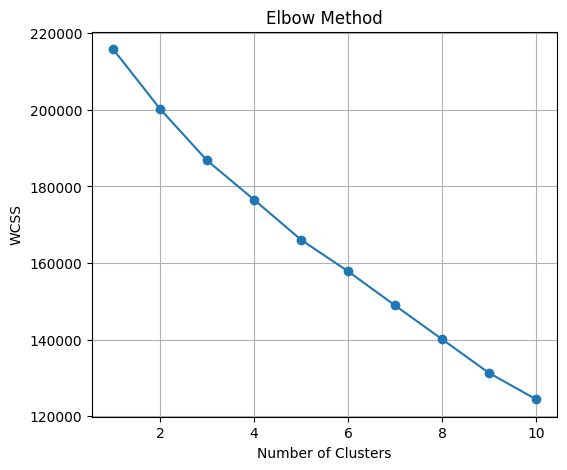

In [11]:
#Elbow method to find the optimal number of clusters (K)
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig("..//outputs/elbow_method.png")
plt.show()
#no elbow is visible, so we will use silhouette score to find the optimal number of clusters

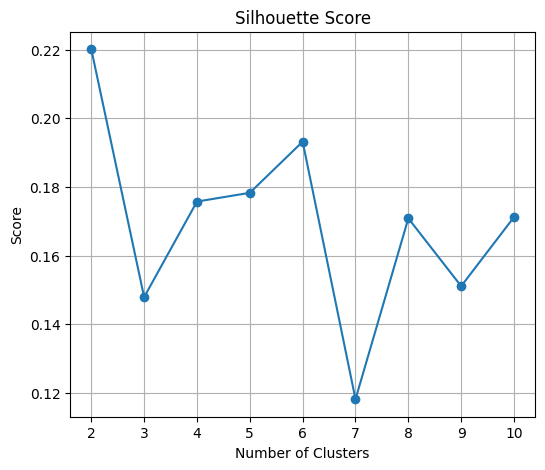

In [12]:
#Silhouette score to find the optimal number of clusters (K)
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X,labels)
    scores.append(score)

plt.figure(figsize=(6,5))
plt.plot(range(2,11),scores,marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.grid(True)
plt.savefig("..//outputs/silhouette_scores.png")
plt.show()
#highest silhouette score is at k=2, so we will use k=2 for our final model

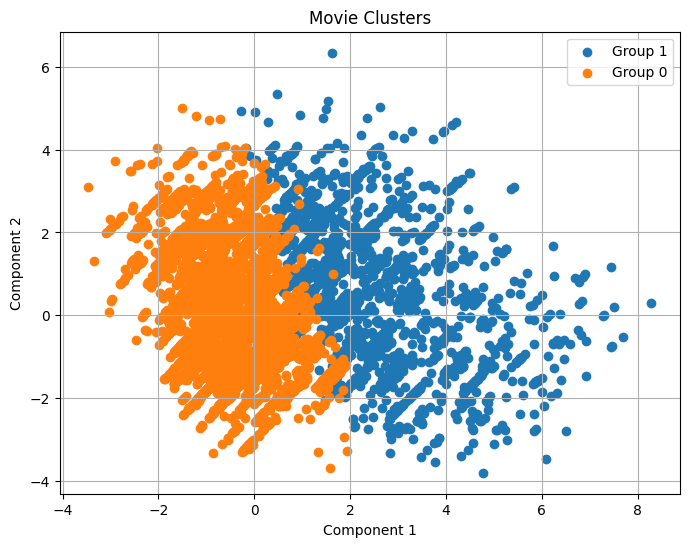

In [13]:
import joblib
optimal_k = 2   #obtained from silhouette score analysis
model = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
df['group'] = model.fit_predict(X)
joblib.dump(model,"..//models/kmeans.pkl")

plt.figure(figsize=(8,6))
for group in df['group'].unique():
    group_data = df[df['group'] == group]
    plt.scatter(group_data['0'],group_data['1'],label=f'Group {group}')

plt.title('Movie Clusters')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.grid(True)
plt.savefig("..//outputs/clustered_movies.png")
plt.show()

In [14]:
print(df['group'].value_counts())
df.to_csv("..//outputs/clustered_movies.csv",index=False)
print("Clustered Data")
print(df.head())

group
0    7990
1    1734
Name: count, dtype: int64
Clustered Data
          0         1         2         3         4         5         6  \
0  6.923529 -0.622405  3.653590  1.650460 -1.074854  1.560218 -0.134682   
1  4.497216 -0.043198  2.216751  0.859241 -0.089031  0.363486  0.425357   
2 -0.090674 -1.454600 -0.192217 -0.157205 -1.862521  0.130831 -0.317642   
3 -0.912260 -1.702799 -0.356695 -0.120277 -1.836550 -0.063194  0.801612   
4  0.190519 -0.716639 -0.589899 -0.174251 -0.881254  0.279559 -0.878279   

          7         8         9  ...        13        14        15        16  \
0  3.449177  0.439344  0.699551  ... -0.255219 -2.794391  3.825341  1.698827   
1  1.278206  0.336701  0.372130  ...  1.690563 -2.313469  2.900070  0.253680   
2  1.969479  0.298862 -0.075284  ...  0.086895  0.210605  0.217335  1.022009   
3  0.227479  0.090094 -0.170911  ...  0.239836  0.542260  0.121233  0.590657   
4  0.975727  0.084691 -0.091573  ... -0.479864 -0.481378  1.107290 -0.227961   

 